/var/folders/tt/_bhqh_rs421c5z9wt2g56__c0000gn/T/ipykernel_9400/4072231602.py:11: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft_circ = QFT(n)


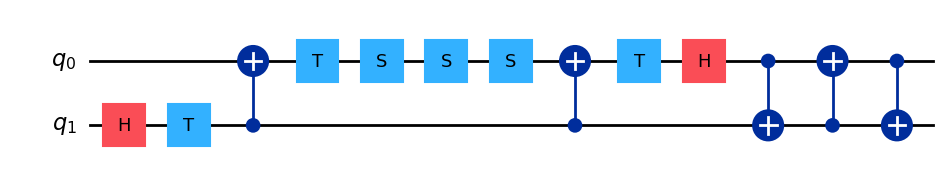

KeyboardInterrupt: 

In [5]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFT

# Generate scalable circuits (e.g., QFT) and transpile to Clifford+T

def create_scalable_clifford_t_circuits():
    circuits = []
    num_qubits_list = [2,3]
    for n in num_qubits_list:
        # QFT circuit
        qft_circ = QFT(n)
        # Transpile to Clifford+T basis
        clifford_t_circ = transpile(qft_circ, basis_gates=["cx", "h", "s", "t"], optimization_level=3)
        circuits.append(clifford_t_circ)
    return circuits

circuits = create_scalable_clifford_t_circuits()
for idx, qc in enumerate(circuits):
    display(qc.draw('mpl'))

In [2]:
# Export transpiled scalable circuits to QASM2 files
import os
import qiskit.qasm2

export_dir = "qasm2_exports"
os.makedirs(export_dir, exist_ok=True)

for idx, qc in enumerate(circuits):
    qasm_str = qiskit.qasm2.dumps(qc)
    filename = os.path.join(export_dir, f"qft_clifford_t_{qc.num_qubits}q_{idx+1}.qasm2")
    with open(filename, "w") as f:
        f.write(qasm_str)
    print(f"Exported {filename}")

Exported qasm2_exports/qft_clifford_t_2q_1.qasm2


In [3]:
# Simulate each circuit to get the statevector and benchmark Qiskit
import time
from qiskit_aer import Aer
from qiskit import transpile

simulator = Aer.get_backend('statevector_simulator')

statevectors = []
timings = []

for idx, qc in enumerate(circuits):
    start = time.time()
    tqc = transpile(qc, simulator)
    result = simulator.run(tqc).result()
    statevector = result.get_statevector()
    elapsed = time.time() - start
    statevectors.append(statevector)
    timings.append(elapsed)
    print(f"Simulated circuit {idx+1} ({qc.num_qubits} qubits) in {elapsed:.4f} seconds")

Simulated circuit 1 (2 qubits) in 0.0465 seconds


In [ ]:
print(statevector)

In [4]:
# Display timing results for benchmarking
import pandas as pd

benchmark_data = {
    "Circuit": [f"QFT {qc.num_qubits}q" for qc in circuits],
    "Qubits": [qc.num_qubits for qc in circuits],
    "Simulation Time (s)": timings
}
df = pd.DataFrame(benchmark_data)
display(df)

,Circuit,Qubits,Simulation Time (s)
0,QFT 2q,2,0.046539


## Benchmarking Clifford+T Circuits and Exporting to QASM2
This notebook generates multiple Clifford+T circuits using Qiskit and exports them to QASM2 format for benchmarking.